In [23]:
import torch
import torch.optim as optim
import torchvision
import numpy as np
from PIL import Image
import os
import glob
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [2]:
import model
import Myloss

In [40]:
def load_image(image_path, size = 512):
    data_lowlight = Image.open(image_path).convert('RGB')
    data_lowlight = data_lowlight.resize((size, size), Image.BILINEAR)
    data_lowlight = (np.asarray(data_lowlight) / 255.0)
    data_lowlight = torch.from_numpy(data_lowlight).float()
    data_lowlight = data_lowlight.permute(2, 0, 1) # CHW format
    data_lowlight = data_lowlight.unsqueeze(0)     # BCHW format
    return data_lowlight

def save_image(tensor, filename):
    torchvision.utils.save_image(tensor, filename)

def calculate_metrics(enhanced_path, ground_truth_path):
    img_e = np.asarray(Image.open(enhanced_path).convert('RGB'))
    img_gt = np.asarray(Image.open(ground_truth_path).convert('RGB'))
    
    val_psnr = psnr(img_gt, img_e)
    val_ssim = ssim(img_gt, img_e, channel_axis=2, data_range=255) 
    
    return val_psnr, val_ssim

def finetune_single_image(lowlight_path, pretrained_weights_path, output_dir, device):
    filename = os.path.basename(lowlight_path)
    
    DCE_net = model.enhance_net_nopool().to(device)
    DCE_net.load_state_dict(torch.load(pretrained_weights_path, map_location=device))
    data_lowlight = load_image(lowlight_path).to(device)
    
    # Run Pretrained Model
    DCE_net.eval()
    with torch.no_grad():
        _, enhanced_baseline, _ = DCE_net(data_lowlight)
        baseline_out_path = os.path.join(output_dir, f"baseline_{filename}")
        save_image(enhanced_baseline, baseline_out_path)
    
    # Image-Specific Fine-Tuning
    DCE_net.load_state_dict(torch.load(pretrained_weights_path, map_location=device))
    DCE_net.train()
    
    learning_rate = 1e-4
    epochs = 30
    
    optimizer = optim.Adam(DCE_net.parameters(), lr=learning_rate, weight_decay=1e-4)
    L_color = Myloss.L_color()
    L_spa = Myloss.L_spa()
    L_exp = Myloss.L_exp(16, 0.6) # Patch size 16, Exposure target 0.6
    L_TV = Myloss.L_TV()

    for epoch in range(epochs):
        optimizer.zero_grad()
        _, enhanced_image, image_alpha = DCE_net(data_lowlight)
        
        Loss_TV = 200 * L_TV(image_alpha)
        Loss_spa = torch.mean(L_spa(enhanced_image, data_lowlight))
        Loss_col = 5 * torch.mean(L_color(enhanced_image))
        Loss_exp = 10 * torch.mean(L_exp(enhanced_image))
        total_loss = Loss_TV + Loss_spa + Loss_col + Loss_exp
        
        total_loss.backward()
        optimizer.step()
        
    DCE_net.eval()
    with torch.no_grad():
        _, enhanced_finetuned, _ = DCE_net(data_lowlight)
        finetuned_out_path = os.path.join(output_dir, f"finetuned_{filename}")
        save_image(enhanced_finetuned, finetuned_out_path)
        
    return baseline_out_path, finetuned_out_path

In [16]:
pretrained_weights = "Zero-DCE_code/snapshots/Epoch99.pth" 
lol_low_dir = "data/LOL/train/"         # Directory containing the 5 low-light images
lol_high_dir = "data/LOL/test/"       # Directory containing the 5 ground truth normal images
smartphone_dir = "data/camera/"   # Directory containing your captured images
output_dir = "output/"

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
result = {}
for filename in os.listdir(lol_low_dir):
    img_path = lol_low_dir + filename
    gt_path = os.path.join(lol_high_dir, 'normal' + filename[3:])
    baseline_path, finetuned_path = finetune_single_image(img_path, pretrained_weights, output_dir, device)
    
    # Calculate Metrics
    base_psnr, base_ssim = calculate_metrics(baseline_path, gt_path)
    ft_psnr, ft_ssim = calculate_metrics(finetuned_path, gt_path)
    result[filename[3:]] = [base_psnr, base_ssim, ft_psnr, ft_ssim]
    
    print(f"Results for {filename}:")
    print(f"  Baseline   -> PSNR: {base_psnr:.2f} dB, SSIM: {base_ssim:.4f}")
    print(f"  Fine-Tuned -> PSNR: {ft_psnr:.2f} dB, SSIM: {ft_ssim:.4f}")
    print("-" * 30)

Results for low00703.png:
  Baseline   -> PSNR: 9.80 dB, SSIM: 0.4080
  Fine-Tuned -> PSNR: 17.21 dB, SSIM: 0.4590
------------------------------
Results for low00718.png:
  Baseline   -> PSNR: 16.80 dB, SSIM: 0.7690
  Fine-Tuned -> PSNR: 12.33 dB, SSIM: 0.6308
------------------------------
Results for low00731.png:
  Baseline   -> PSNR: 25.76 dB, SSIM: 0.8289
  Fine-Tuned -> PSNR: 13.42 dB, SSIM: 0.7077
------------------------------
Results for low00765.png:
  Baseline   -> PSNR: 17.30 dB, SSIM: 0.6690
  Fine-Tuned -> PSNR: 10.52 dB, SSIM: 0.4322
------------------------------
Results for low00783.png:
  Baseline   -> PSNR: 15.66 dB, SSIM: 0.7149
  Fine-Tuned -> PSNR: 12.79 dB, SSIM: 0.5995
------------------------------


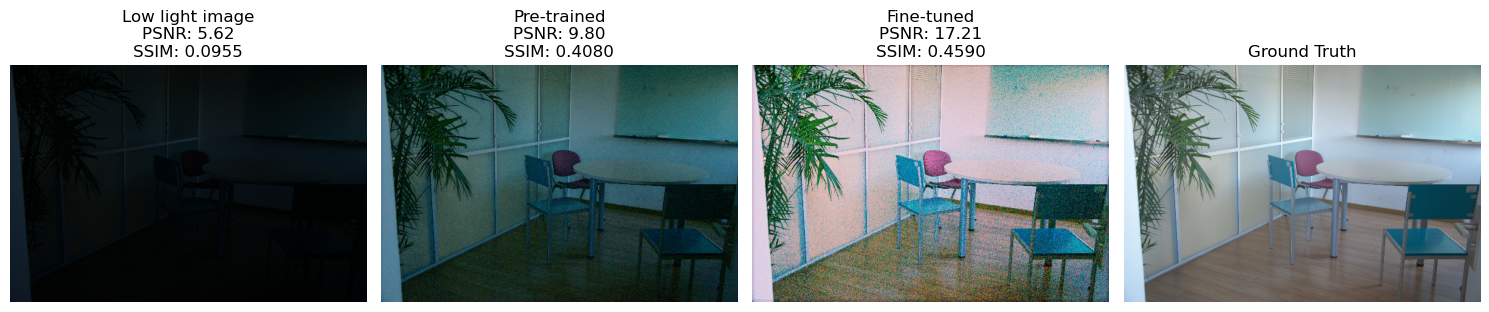

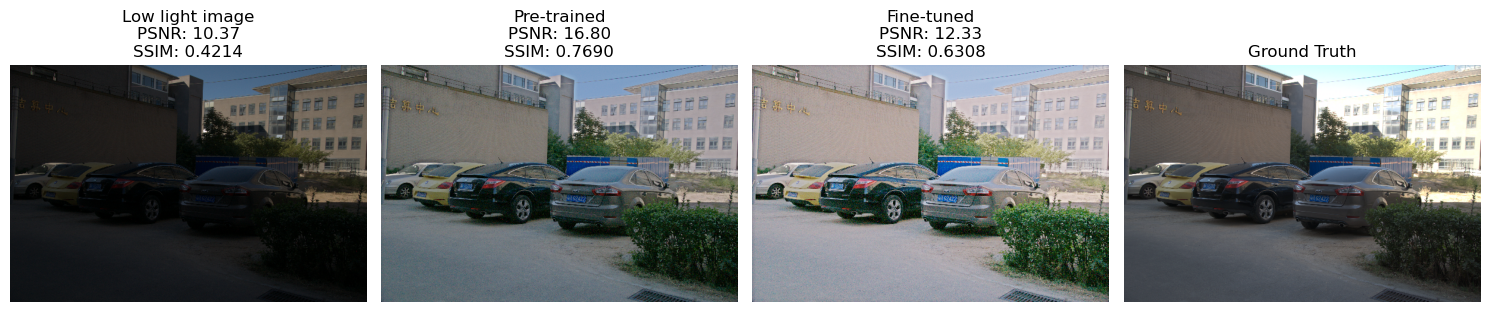

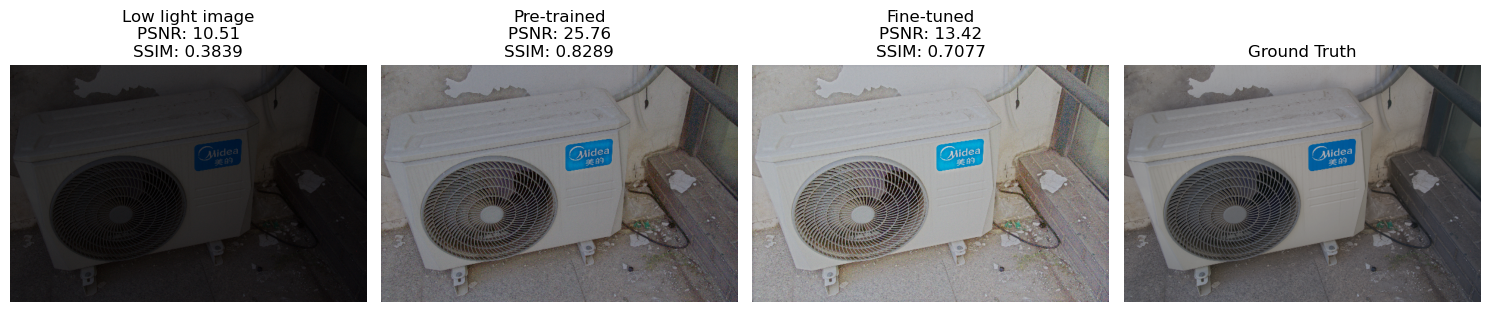

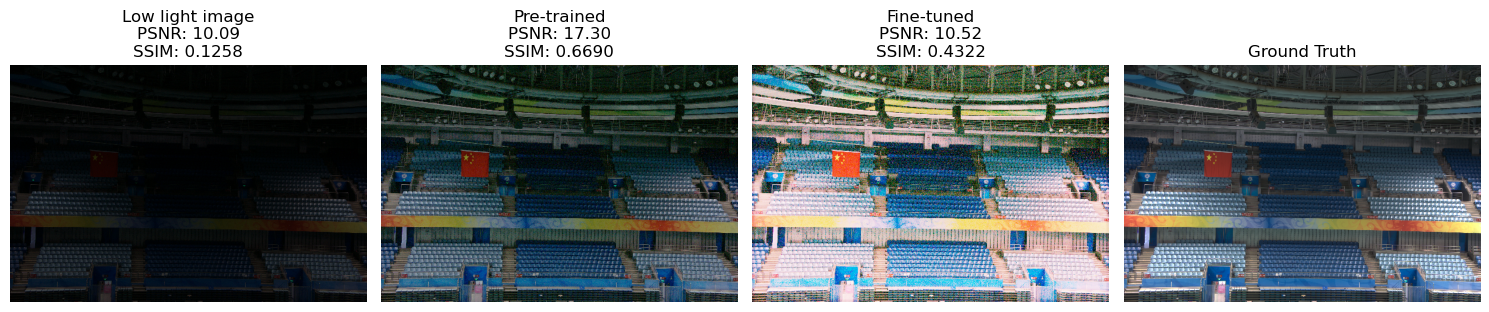

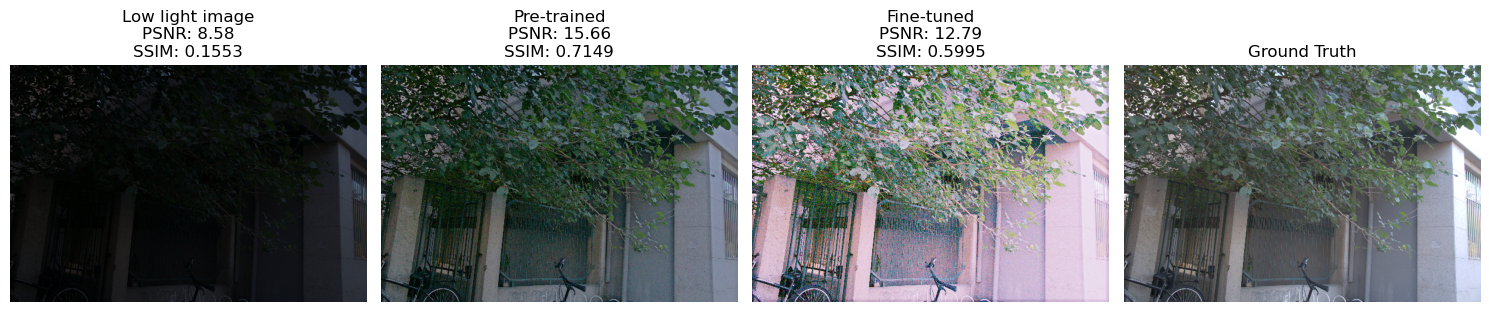

In [34]:
for img_name, res in result.items():
    fig, axes = plt.subplots(1, 4, figsize=(15,8))
    org_image = np.array(Image.open(lol_low_dir + 'low' + img_name))
    base_image = np.array(Image.open(output_dir + 'baseline_low' + img_name))
    ft_image = np.array(Image.open(output_dir + 'finetuned_low' + img_name))
    gt_image = np.array(Image.open(lol_high_dir + 'normal' + img_name))
    org_psnr, org_ssim = calculate_metrics(lol_low_dir + 'low' + img_name, lol_high_dir + 'normal' + img_name)
    axes[0].imshow(org_image)
    axes[0].set_title(f"Low light image\nPSNR: {org_psnr:.2f}\nSSIM: {org_ssim:.4f}")
    axes[0].axis('off')
    axes[1].imshow(base_image)
    axes[1].set_title(f"Pre-trained\nPSNR: {res[0]:.2f}\nSSIM: {res[1]:.4f}")
    axes[1].axis('off')
    axes[2].imshow(ft_image)
    axes[2].set_title(f"Fine-tuned\nPSNR: {res[2]:.2f}\nSSIM: {res[3]:.4f}")
    axes[2].axis('off')
    axes[3].imshow(gt_image)
    axes[3].set_title("Ground Truth")
    axes[3].axis('off')
    plt.tight_layout()
    plt.show()

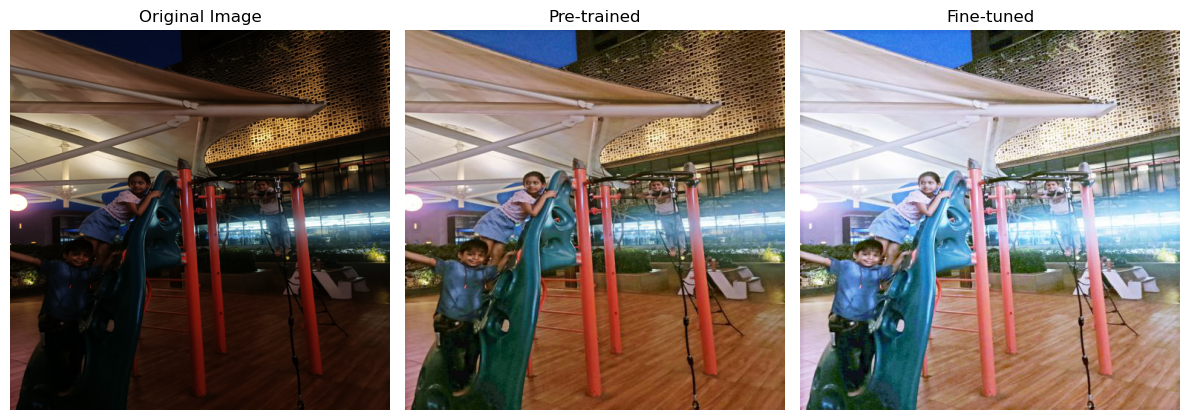

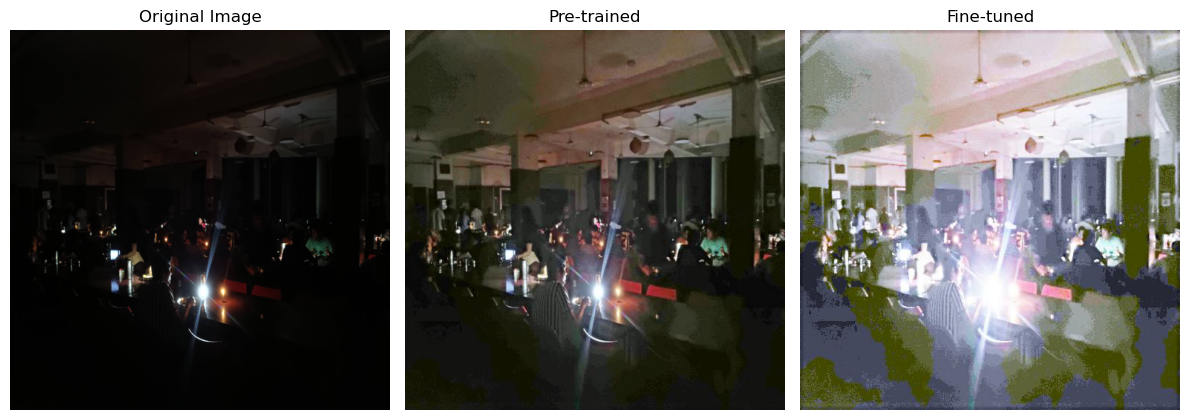

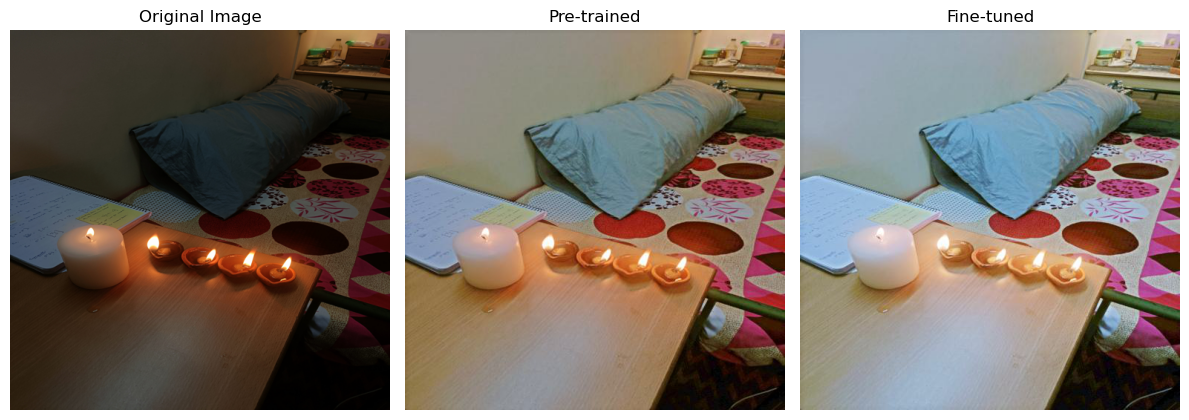

In [43]:
for filename in os.listdir(smartphone_dir):
    img_path = smartphone_dir + filename
    baseline_path, finetuned_path = finetune_single_image(img_path, pretrained_weights, output_dir, device)

    org_image = np.array(Image.open(img_path).resize((512, 512)))
    base_image = np.array(Image.open(baseline_path))
    ft_image = np.array(Image.open(finetuned_path))

    fig, axes = plt.subplots(1, 3, figsize=(12,8))
    axes[0].imshow(org_image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    axes[1].imshow(base_image)
    axes[1].set_title(f"Pre-trained")
    axes[1].axis('off')
    axes[2].imshow(ft_image)
    axes[2].set_title(f"Fine-tuned")
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()